# Figure A.1 — Simulation of Beliefs Over Time Under Different Updating Rules

Reproduces **Figure A.1** of *The Spiral of Silence*.


**Outputs**, written to `Output/`:

| file | contents |
|---|---|
| `figure_A1.png` | the 2x2 exhibit as it appears in the paper |
| `figure_A1_bayesian.png` | individual panels, in case the LaTeX source |
| `figure_A1_prior_projection.png` | includes them separately |
| `figure_A1_5050.png` | |
| `figure_A1_type_projection.png` | |

**Reproducibility.** All random draws are seeded as a deterministic function of the
loop indices, so results are identical across runs, machines and thread counts. The
last cell verifies this.

In [1]:
import math
import os

import matplotlib.pyplot as plt
import numpy as np
from numba import njit, prange

## 1. Parameters

These are the values reported in the note to Figure A.1.

In [2]:
PACKAGE_ROOT = ".."      # this notebook lives in Code/, so the package root is one level up
OUTDIR = os.path.join(PACKAGE_ROOT, "Output")

N_POP = 1000        # population size N
N_AGREE = 450       # privately agree with the socially appropriate view (45%)
N_DISAGREE = 550    # privately disagree (55%)

A0, B0 = 5.5, 4.5   # Beta prior hyperparameters, common across individuals
PRIOR_SD = 0.15     # individual-level noise multiplying A0, B0 at t = 0

V0, SIGMA_V = 0.0, 1.0   # intrinsic value of speaking up: v ~ N(V0, SIGMA_V)
CHI = 2.0                # social cost parameter
T = 50                   # iterations
M_LIST = np.array([0.0, 0.2, 0.8, 1.0])   # fraction paying attention to silence
N_REPS = 20              # simulation replications per m
BASE_SEED = 20260820     # master seed; see the seeding note in section 3

TRUE_P = N_AGREE / N_POP   # 0.45, the horizontal dashed line in the figure

# Belief-updating rules. Only the treatment of SILENT individuals differs;
# the expression decision is identical across rules.
RULE_BAYESIAN = 0          # attribute silence using the equilibrium rho(pa)
RULE_5050 = 1              # treat silence as 50% agree / 50% disagree
RULE_PRIOR_PROJECTION = 2  # attribute silence in proportion to one's own prior
RULE_TYPE_PROJECTION = 3   # attribute all silence to one's own private type

# listed in the panel order used in the paper (top-left, top-right, bottom-left, bottom-right)
RULES = [
    (RULE_BAYESIAN, "Bayesian", "bayesian"),
    (RULE_PRIOR_PROJECTION, "Prior Projection", "prior_projection"),
    (RULE_5050, "50/50 Updating Rule", "5050"),
    (RULE_TYPE_PROJECTION, "Type Projection", "type_projection"),
]

os.makedirs(OUTDIR, exist_ok=True)
print("writing output to:", os.path.abspath(OUTDIR))

writing output to: /Users/yihong/Desktop/Silence Replicate Final/Output


## 2. Equilibrium rho(pa)

`rho(pa)` is the share of silent individuals who privately agree, solved as the fixed point and then pre-computed on a grid so the inner simulation loop only has to interpolate.

Note `math.erf`, not `np.math.erf` — the latter was removed in NumPy 2.0.

In [3]:
_INV_SQRT2 = 1.0 / math.sqrt(2.0)


@njit
def norm_cdf(x):
    return 0.5 * (1.0 + math.erf(x * _INV_SQRT2))


@njit
def solve_rho(pa, chi, v0, sigma_v):
    """Fixed point of rho = pa*G0 / (pa*G0 + (1-pa)*G(chi*pa*rho))."""
    g0 = norm_cdf(-v0 / sigma_v)
    rho = 0.5
    for _ in range(50):
        num = pa * g0
        den = num + (1.0 - pa) * norm_cdf((chi * pa * rho - v0) / sigma_v)
        rho = num / den
    return rho


@njit
def interp_rho(pa, pa_grid, rho_vals):
    """Linear interpolation of rho on a uniform grid over [0, 1]."""
    if pa <= 0.0:
        return rho_vals[0]
    if pa >= 1.0:
        return rho_vals[-1]
    idx = int(pa * (pa_grid.size - 1))
    x0, x1 = pa_grid[idx], pa_grid[idx + 1]
    y0, y1 = rho_vals[idx], rho_vals[idx + 1]
    return y0 + (y1 - y0) * (pa - x0) / (x1 - x0)


def build_rho_grid(chi, v0, sigma_v, n_grid=51):
    pa_grid = np.linspace(0.0, 1.0, n_grid)
    rho_vals = np.empty_like(pa_grid)
    for i in range(pa_grid.size):
        rho_vals[i] = solve_rho(pa_grid[i], chi, v0, sigma_v)
    return pa_grid, rho_vals


pa_grid, rho_vals = build_rho_grid(CHI, V0, SIGMA_V)
print("rho(0.25) =", round(interp_rho(0.25, pa_grid, rho_vals), 4))

rho(0.25) = 0.2337


## 3. Core simulation

### Seeding

numba's `np.random` state is **thread-local**, so a single `np.random.seed()` call outside
the parallel region does *not* make a `prange` loop reproducible — which thread executes
which iteration is not fixed. Seeding at the top of every `(m, replication)` block with a
value derived from the loop indices makes the draws a deterministic function of the indices
alone, so results are identical across runs, machines and thread counts.

### Structure

All four rules share the same expression decision and differ only in how silence enters the
belief update, so they are one function with a `rule` switch rather than four near-duplicate
copies.

In [4]:
@njit(parallel=True)
def run_simulations(rule, n_reps, n_pop, n_agree, a0, b0, prior_sd,
                    v0, sigma_v, chi, n_iter, m_list, pa_grid, rho_vals,
                    base_seed):
    n_m = m_list.size
    n_dis = n_pop - n_agree

    hist0 = np.zeros((n_m, n_reps, n_iter + 1))     # mean belief, lambda = 0
    hist1 = np.zeros((n_m, n_reps, n_iter + 1))     # mean belief, lambda = 1
    hist_all = np.zeros((n_m, n_reps, n_iter + 1))  # population mean belief

    for im in prange(n_m):
        m = m_list[im]
        for rep in range(n_reps):
            np.random.seed(base_seed + 1000 * im + rep)   # <-- see seeding note above

            # attention indicator lambda, exact proportion m within each type
            lamb_a = np.zeros(n_agree, dtype=np.int32)
            lamb_d = np.zeros(n_dis, dtype=np.int32)
            for i in range(int(n_agree * m)):
                lamb_a[i] = 1
            for i in range(int(n_dis * m)):
                lamb_d[i] = 1
            np.random.shuffle(lamb_a)
            np.random.shuffle(lamb_d)

            a_arr = np.empty(n_pop)
            b_arr = np.empty(n_pop)
            pa_arr = np.empty(n_pop)
            theta = np.empty(n_pop, np.int32)
            lamb = np.empty(n_pop, np.int32)

            for i in range(n_pop):
                a_arr[i] = a0 * np.random.normal(1.0, prior_sd)
                b_arr[i] = b0 * np.random.normal(1.0, prior_sd)
                pa_arr[i] = a_arr[i] / (a_arr[i] + b_arr[i])
                if i < n_agree:
                    theta[i] = 1
                    lamb[i] = lamb_a[i]
                else:
                    theta[i] = 0
                    lamb[i] = lamb_d[i - n_agree]

            # record t = 0, before any updating
            s0 = 0.0; c0 = 0
            s1 = 0.0; c1 = 0
            sa = 0.0
            for i in range(n_pop):
                if lamb[i] == 0:
                    s0 += pa_arr[i]; c0 += 1
                else:
                    s1 += pa_arr[i]; c1 += 1
                sa += pa_arr[i]
            hist0[im, rep, 0] = s0 / c0 if c0 > 0 else np.nan
            hist1[im, rep, 0] = s1 / c1 if c1 > 0 else np.nan
            hist_all[im, rep, 0] = sa / n_pop

            for t in range(n_iter):
                # --- expression decisions (identical across rules) ------------
                express = np.zeros(n_pop, np.int32)
                for i in range(n_pop):
                    v = np.random.normal(v0, sigma_v)
                    if theta[i] == 1:
                        express[i] = 1 if v > 0.0 else 0
                    else:
                        cost = chi * pa_arr[i]
                        if lamb[i] == 1:
                            cost *= interp_rho(pa_arr[i], pa_grid, rho_vals)
                        express[i] = 1 if (v - cost) > 0.0 else 0

                n_expr_a = 0
                n_expr_d = 0
                for i in range(n_pop):
                    if express[i] == 1:
                        if theta[i] == 1:
                            n_expr_a += 1
                        else:
                            n_expr_d += 1
                n_silent_total = n_pop - n_expr_a - n_expr_d

                # --- belief update (this is what differs across rules) --------
                for i in range(n_pop):
                    a_new = a_arr[i] + n_expr_a
                    b_new = b_arr[i] + n_expr_d
                    silent = lamb[i] * n_silent_total

                    if rule == RULE_BAYESIAN:
                        r = interp_rho(pa_arr[i], pa_grid, rho_vals)
                        a_new += silent * r
                        b_new += silent * (1.0 - r)
                    elif rule == RULE_5050:
                        a_new += 0.5 * silent
                        b_new += 0.5 * silent
                    elif rule == RULE_PRIOR_PROJECTION:
                        p_prior = pa_arr[i]
                        a_new += silent * p_prior
                        b_new += silent * (1.0 - p_prior)
                    else:   # RULE_TYPE_PROJECTION
                        if theta[i] == 1:
                            a_new += silent
                        else:
                            b_new += silent

                    a_arr[i] = a_new
                    b_arr[i] = b_new
                    pa_arr[i] = a_new / (a_new + b_new)

                s0 = 0.0; c0 = 0
                s1 = 0.0; c1 = 0
                sa = 0.0
                for i in range(n_pop):
                    if lamb[i] == 0:
                        s0 += pa_arr[i]; c0 += 1
                    else:
                        s1 += pa_arr[i]; c1 += 1
                    sa += pa_arr[i]
                hist0[im, rep, t + 1] = s0 / c0 if c0 > 0 else np.nan
                hist1[im, rep, t + 1] = s1 / c1 if c1 > 0 else np.nan
                hist_all[im, rep, t + 1] = sa / n_pop

    return hist0, hist1, hist_all

## 4. Plotting helpers

In [5]:
def summarise(arr):
    """Mean and 95% simulation interval across replications."""
    return (arr.mean(axis=1),
            np.percentile(arr, 2.5, axis=1),
            np.percentile(arr, 97.5, axis=1))


def draw_panel(ax, x, mean, lo, hi, title):
    colors = ["C0", "C1", "C2", "C3"]
    for i, m in enumerate(M_LIST):
        ax.plot(x, mean[i], color=colors[i], label=f"m={m:.1f}")
        ax.fill_between(x, lo[i], hi[i], color=colors[i], alpha=0.2)
    ax.axhline(TRUE_P, linestyle="--", linewidth=1.5, color="k", alpha=0.8,
               label=f"true p={TRUE_P:g}")
    ax.set_title(title, fontsize=9)
    ax.set_xlabel("Iteration")
    ax.set_ylabel(r"$E[\pi]$")
    ax.grid(True)

## 5. Run the four rules and save the individual panels

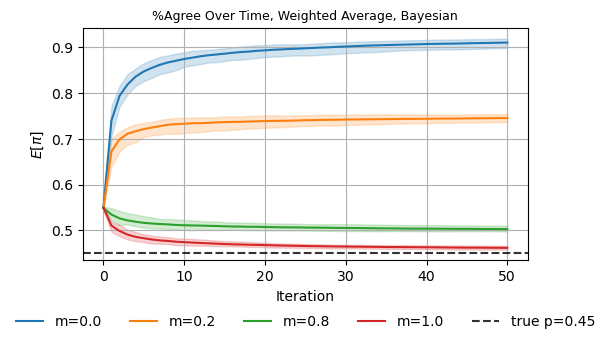

Bayesian             final mean %Agree by m {0.0: 0.9103, 0.2: 0.7454, 0.8: 0.5028, 1.0: 0.4619}


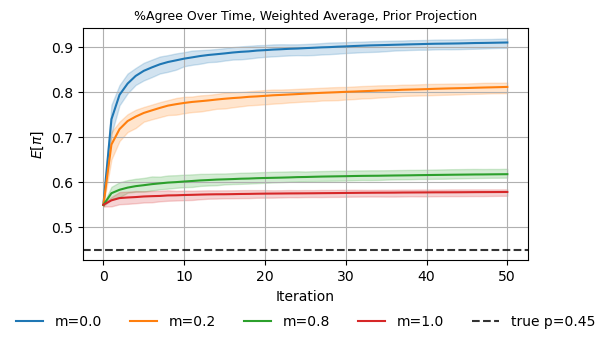

Prior Projection     final mean %Agree by m {0.0: 0.9103, 0.2: 0.8115, 0.8: 0.6176, 1.0: 0.578}


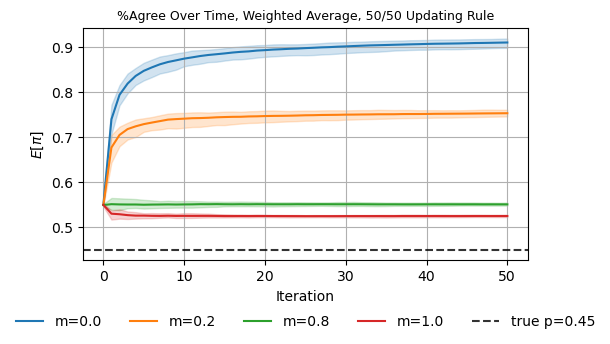

50/50 Updating Rule  final mean %Agree by m {0.0: 0.9103, 0.2: 0.7531, 0.8: 0.5505, 1.0: 0.5246}


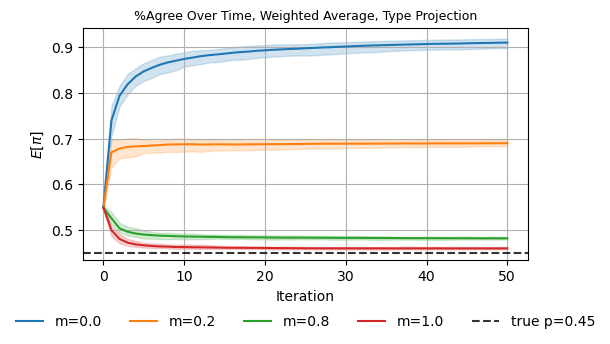

Type Projection      final mean %Agree by m {0.0: 0.9103, 0.2: 0.6902, 0.8: 0.4821, 1.0: 0.4601}


In [6]:
x = np.arange(0, T + 1)
results = {}

for rule, label, slug in RULES:
    _, _, hist_all = run_simulations(
        rule, N_REPS, N_POP, N_AGREE, A0, B0, PRIOR_SD,
        V0, SIGMA_V, CHI, T, M_LIST, pa_grid, rho_vals, BASE_SEED)
    results[rule] = summarise(hist_all)

    fig, ax = plt.subplots(figsize=(6, 4))
    draw_panel(ax, x, *results[rule],
               f"%Agree Over Time, Weighted Average, {label}")
    ax.legend(loc="upper center", bbox_to_anchor=(0.5, -0.18),
              ncol=len(M_LIST) + 1, frameon=False)
    fig.tight_layout(rect=[0, 0.08, 1, 1])
    fig.savefig(os.path.join(OUTDIR, f"figure_A1_{slug}.png"), dpi=300)
    plt.show()

    final = results[rule][0][:, -1]
    print(f"{label:20s} final mean %Agree by m "
          f"{dict(zip(M_LIST, np.round(final, 4)))}")

## 6. The combined 2x2 exhibit

This is the file to include in the paper as Figure A.1.

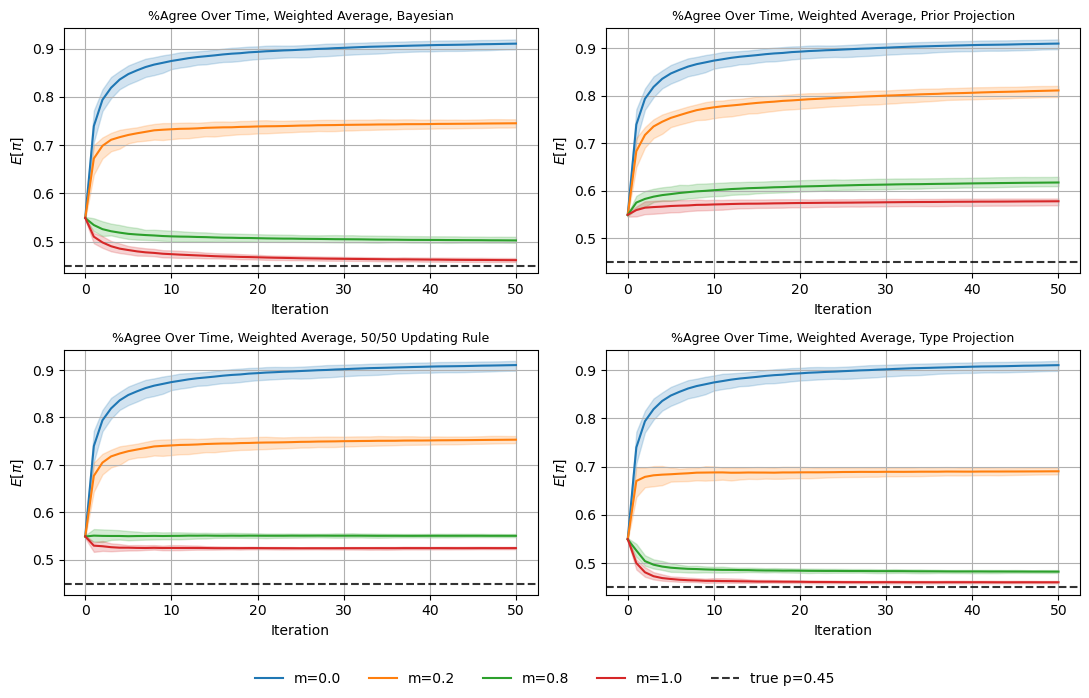

wrote figure_A1.png and 4 panel files to /Users/yihong/Desktop/Silence Replicate Final/Output


In [7]:
fig, axes = plt.subplots(2, 2, figsize=(11, 7))
for ax, (rule, label, _) in zip(axes.ravel(), RULES):
    draw_panel(ax, x, *results[rule],
               f"%Agree Over Time, Weighted Average, {label}")
handles, labels = axes[0, 0].get_legend_handles_labels()
fig.legend(handles, labels, loc="lower center",
           ncol=len(M_LIST) + 1, frameon=False)
fig.tight_layout(rect=[0, 0.06, 1, 1])
fig.savefig(os.path.join(OUTDIR, "figure_A1.png"), dpi=300)
plt.show()

print("wrote figure_A1.png and 4 panel files to", os.path.abspath(OUTDIR))

## 7. Reproducibility check

Re-runs the Bayesian rule and confirms the result is bit-identical to the run above.
A replicator can also set `NUMBA_NUM_THREADS` to different values before starting the
kernel and confirm the same hash.

In [8]:
import hashlib

_, _, again = run_simulations(
    RULE_BAYESIAN, N_REPS, N_POP, N_AGREE, A0, B0, PRIOR_SD,
    V0, SIGMA_V, CHI, T, M_LIST, pa_grid, rho_vals, BASE_SEED)

digest = hashlib.sha256(np.ascontiguousarray(again)).hexdigest()[:16]
print("SHA-256 (first 16 hex) of the Bayesian result array:", digest)
assert np.array_equal(again.mean(axis=1), results[RULE_BAYESIAN][0]), \
    "re-run did not reproduce the first run"
print("OK: re-run reproduces the first run exactly")

SHA-256 (first 16 hex) of the Bayesian result array: 525bea03005f1595
OK: re-run reproduces the first run exactly
